# Centrix LASSO Centroiding — Step-by-Step Walkthrough

This notebook demonstrates how the **Centrix centroider** works, step by step.
Centrix replaces the onboard centroiding of the Thermo Stellar linear ion trap
using **non-negative LASSO regression** with Gaussian basis functions.

**The problem:** The Stellar's onboard centroider places ~1 centroid per Da.
When two signals fall within 1 Da of each other (common in DIA), they collapse
into a single incorrect centroid. Centrix deconvolutes these overlapping signals.

**The solution:** Model the profile signal as a sparse sum of Gaussians:

$$y(m/z) = \sum_j \beta_j \cdot \exp\!\left(-\frac{(m/z - g_j)^2}{2\sigma^2}\right) + \varepsilon$$

and solve via non-negative LASSO:

$$\min_{\beta \geq 0} \;\frac{1}{2}\|y - A\beta\|^2 + \lambda\|\beta\|_1$$

Each non-zero $\beta_j$ corresponds to a detected centroid at grid position $g_j$.

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from matplotlib.collections import LineCollection

%matplotlib inline
plt.rcParams.update({
    'figure.figsize': (14, 5),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

## Simulate a Profile Mass Spectrum

We create a synthetic MS2 spectrum mimicking the Thermo Stellar at 125 kTh/s scan rate:
- **Grid spacing:** 1/8 = 0.125 Th (firmware-fixed for MS2)
- **Peak σ:** 0.340 Da (125 kTh/s FWHM ≈ 0.8 Da)
- **Three peaks**, two of which are only **0.5 Da apart** — the scenario Centrix is designed to solve

In [56]:
# Instrument parameters (Stellar MS2 at 125 kTh/s)
SIGMA = 0.340       # Gaussian σ in Da
GRID_SPACING = 0.125 # Profile grid spacing (1/8 Th for MS2)

# True peak positions and amplitudes
true_peaks = [
    (500.00, 8000.0),   # Peak A
    (500.50, 5000.0),   # Peak B — only 0.5 Da from A (< 1 Da overlap!)
    (503.25, 12000.0),  # Peak C — well-separated
]

# Generate profile data on a uniform grid
mz = np.arange(498.0, 506.0, GRID_SPACING)
n_pts = len(mz)

# Sum of Gaussians + noise
np.random.seed(42)
noise_level = 50.0
signal = np.zeros(n_pts)
for center, amplitude in true_peaks:
    signal += amplitude * np.exp(-0.5 * ((mz - center) / SIGMA) ** 2)
intensity = signal + np.random.normal(0, noise_level, n_pts)
intensity = np.maximum(intensity, 0)  # no negative intensities

print(f"Profile: {n_pts} data points, {mz[0]:.1f}–{mz[-1]:.1f} m/z")
print(f"True peaks: {[f'{c:.2f} Da ({a:.0f})' for c, a in true_peaks]}")

Profile: 64 data points, 498.0–505.9 m/z
True peaks: ['500.00 Da (8000)', '500.50 Da (5000)', '503.25 Da (12000)']


## Visualize the Raw Profile Spectrum

This is what the instrument outputs in profile mode. Note how peaks A and B
(0.5 Da apart) appear as a **single merged hump** — the onboard Thermo centroider
would place one centroid somewhere between them, losing both true positions.

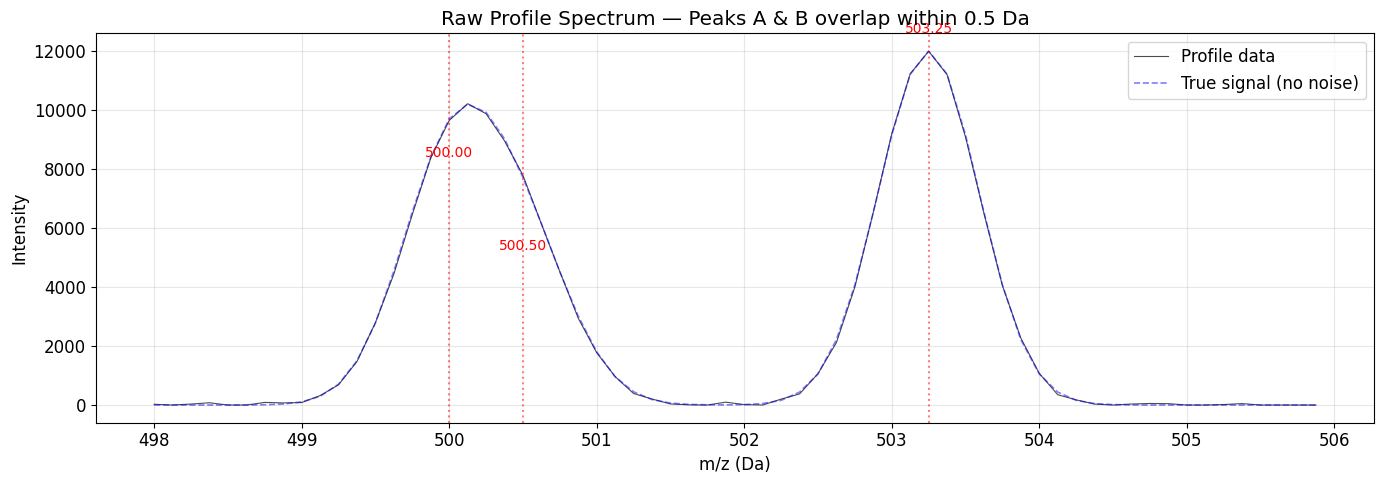

In [57]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(mz, intensity, 'k-', lw=0.8, alpha=0.7, label='Profile data')
ax.plot(mz, signal, 'b--', lw=1.2, alpha=0.5, label='True signal (no noise)')

for center, amplitude in true_peaks:
    ax.axvline(center, color='red', ls=':', alpha=0.5)
    ax.annotate(f'{center:.2f}', xy=(center, amplitude * 1.05),
                ha='center', fontsize=10, color='red')

ax.set_xlabel('m/z (Da)')
ax.set_ylabel('Intensity')
ax.set_title('Raw Profile Spectrum — Peaks A & B overlap within 0.5 Da')
ax.legend()
plt.tight_layout()
plt.show()

## Step 1: Noise Estimation

Centrix uses a fast **order-statistics** approach:
- **Baseline:** 10th percentile of sorted intensities
- **Noise σ:** IQR / 1.349 (robust Gaussian σ estimator)
- **Signal threshold:** baseline + N × noise_σ (default N = 3)

Baseline:    0.0
Noise σ:     3328.5
Threshold:   4992.8  (baseline + 1.5×σ)


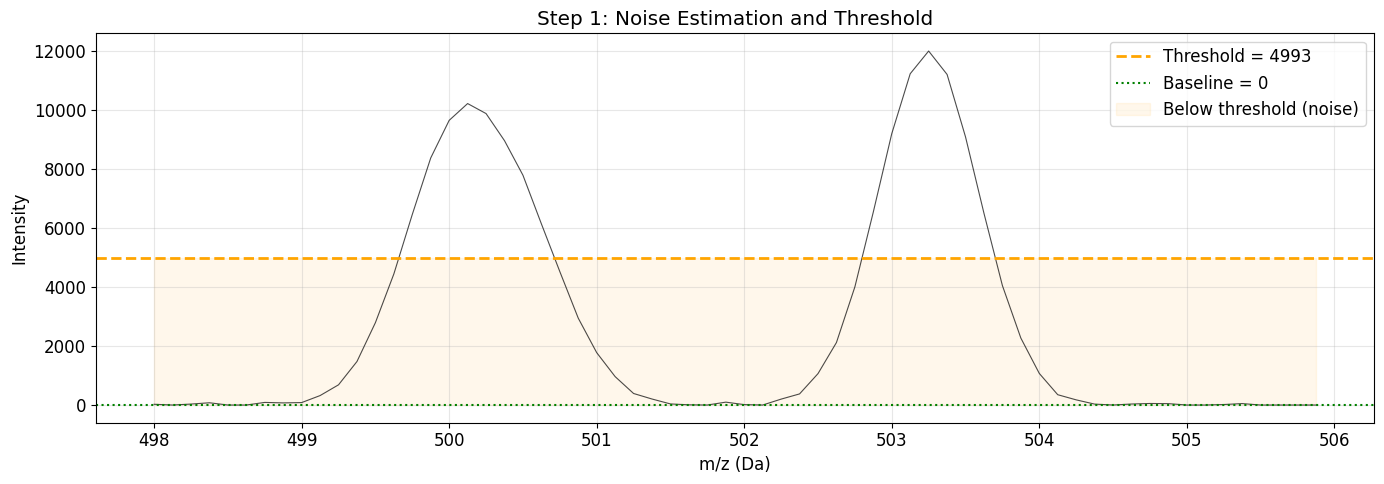

In [58]:
def rough_noise_estimate(intensity):
    """Centrix rough noise estimation (matches src/noise.rs)."""
    sorted_i = np.sort(intensity)
    n = len(sorted_i)
    baseline = sorted_i[int(0.10 * n)]  # 10th percentile
    q25 = sorted_i[int(0.25 * n)]
    q75 = sorted_i[int(0.75 * n)]
    noise_sigma = (q75 - q25) / 1.349   # IQR-based robust σ
    noise_sigma = max(noise_sigma, max(0.10 * baseline, 1.0))  # floor
    return float(baseline), float(noise_sigma)

SIGNAL_THRESHOLD_SIGMA = 1.5  # default
baseline, noise_sigma = rough_noise_estimate(intensity)
threshold = baseline + SIGNAL_THRESHOLD_SIGMA * noise_sigma

print(f"Baseline:    {baseline:.1f}")
print(f"Noise σ:     {noise_sigma:.1f}")
print(f"Threshold:   {threshold:.1f}  (baseline + {SIGNAL_THRESHOLD_SIGMA}×σ)")

# Visualize
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(mz, intensity, 'k-', lw=0.8, alpha=0.7)
ax.axhline(threshold, color='orange', ls='--', lw=2, label=f'Threshold = {threshold:.0f}')
ax.axhline(baseline, color='green', ls=':', lw=1.5, label=f'Baseline = {baseline:.0f}')
ax.fill_between(mz, 0, threshold, alpha=0.08, color='orange', label='Below threshold (noise)')
ax.set_xlabel('m/z (Da)')
ax.set_ylabel('Intensity')
ax.set_title('Step 1: Noise Estimation and Threshold')
ax.legend()
plt.tight_layout()
plt.show()

### How the Noise Estimate Works — Intensity Histogram

The key insight is the same as in the **Horn/Hastings/O'Brien THRASH** paper
(JASMS 2000): in a typical mass spectrum, **most data points are noise**, not signal.
The intensity histogram is dominated by a large low-intensity peak corresponding
to the noise floor. True signal peaks ride above this bulk distribution.

THRASH used the **most frequent intensity** (histogram mode) as the noise estimate.
Centrix uses a more robust approach:

1. **Sort all intensities** in the spectrum
2. **Baseline** = 10th percentile (P10) — the intensity floor
3. **Noise σ** = IQR / 1.349 = (P75 − P25) / 1.349

The IQR/1.349 formula exploits the fact that for a Gaussian distribution,
IQR = 1.349σ. Since the vast majority of points are noise (Gaussian-distributed),
the IQR of all intensities is dominated by the noise distribution and gives a
robust σ estimate — unaffected by the few signal points in the upper tail.

The cell below demonstrates this by plotting the intensity histogram, marking
the percentiles, and showing how the signal points form a negligible right tail.

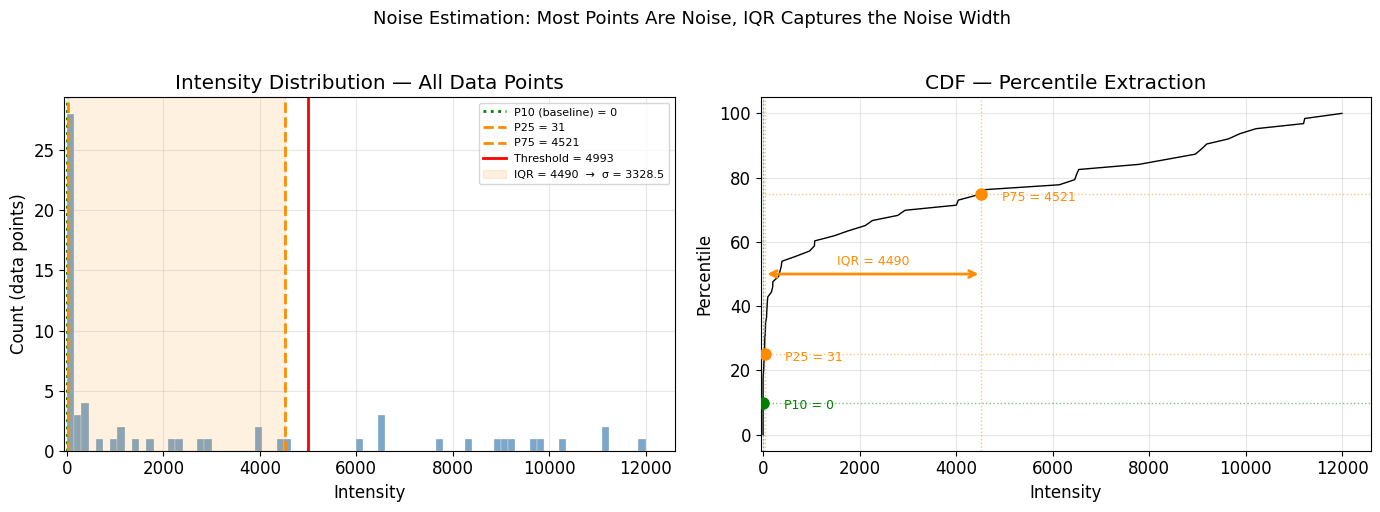


64 total data points:
  49 (76.6%) below threshold — noise/baseline
  15 (23.4%) above threshold — signal

IQR = P75 − P25 = 4521 − 31 = 4490
Noise σ = IQR / 1.349 = 4490 / 1.349 = 3328.5

Compare to THRASH: mode (most frequent intensity) ≈ baseline.
Centrix uses IQR instead of mode — more robust with discrete/sparse histograms.


In [59]:
# --- Intensity histogram: visualizing why IQR captures noise ---

sorted_i = np.sort(intensity)
n = len(sorted_i)
p10 = sorted_i[int(0.10 * n)]
p25 = sorted_i[int(0.25 * n)]
p75 = sorted_i[int(0.75 * n)]
iqr = p75 - p25
iqr_sigma = iqr / 1.349

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Left panel: intensity histogram ---
ax1.hist(intensity, bins=80, color='steelblue', alpha=0.7, edgecolor='white', lw=0.3)
for pval, label, color, ls in [
    (p10, f'P10 (baseline) = {p10:.0f}', 'green', ':'),
    (p25, f'P25 = {p25:.0f}', 'darkorange', '--'),
    (p75, f'P75 = {p75:.0f}', 'darkorange', '--'),
    (threshold, f'Threshold = {threshold:.0f}', 'red', '-'),
]:
    ax1.axvline(pval, color=color, ls=ls, lw=2, label=label)

# Shade the IQR region
ax1.axvspan(p25, p75, alpha=0.12, color='darkorange', label=f'IQR = {iqr:.0f}  →  σ = {iqr_sigma:.1f}')

ax1.set_xlabel('Intensity')
ax1.set_ylabel('Count (data points)')
ax1.set_title('Intensity Distribution — All Data Points')
ax1.legend(fontsize=8, loc='upper right')
ax1.set_xlim(left=-50)

# --- Right panel: CDF (sorted intensities) showing percentile extraction ---
pct = np.linspace(0, 100, n)
ax2.plot(sorted_i, pct, 'k-', lw=1)
for pval, plevel, color in [(p10, 10, 'green'), (p25, 25, 'darkorange'), (p75, 75, 'darkorange')]:
    ax2.axhline(plevel, color=color, ls=':', lw=1, alpha=0.5)
    ax2.axvline(pval, color=color, ls=':', lw=1, alpha=0.5)
    ax2.plot(pval, plevel, 'o', color=color, ms=8, zorder=5)
    ax2.annotate(f'P{plevel} = {pval:.0f}', xy=(pval, plevel),
                 xytext=(15, -5), textcoords='offset points', fontsize=9, color=color)

# Annotate the IQR bracket
ax2.annotate('', xy=(p75, 50), xytext=(p25, 50),
             arrowprops=dict(arrowstyle='<->', color='darkorange', lw=2))
ax2.text((p25 + p75) / 2, 53, f'IQR = {iqr:.0f}', ha='center', fontsize=9, color='darkorange')

ax2.set_xlabel('Intensity')
ax2.set_ylabel('Percentile')
ax2.set_title('CDF — Percentile Extraction')
ax2.set_xlim(left=-50)

fig.suptitle('Noise Estimation: Most Points Are Noise, IQR Captures the Noise Width', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Count signal vs noise points
n_above = np.sum(intensity > threshold)
print(f"\n{n} total data points:")
print(f"  {n - n_above} ({100*(n-n_above)/n:.1f}%) below threshold — noise/baseline")
print(f"  {n_above} ({100*n_above/n:.1f}%) above threshold — signal")
print(f"\nIQR = P75 − P25 = {p75:.0f} − {p25:.0f} = {iqr:.0f}")
print(f"Noise σ = IQR / 1.349 = {iqr:.0f} / 1.349 = {iqr_sigma:.1f}")
print(f"\nCompare to THRASH: mode (most frequent intensity) ≈ baseline.")
print(f"Centrix uses IQR instead of mode — more robust with discrete/sparse histograms.")

### Noise Estimation on a Real Spectrum

The synthetic example above has a simple, flat noise floor. Real LIT spectra
from a Thermo Fusion Lumos look quite different — let's load **spectrum #100**
from a GluFib infusion experiment (Rapid scan rate, 67 kTh/s) and apply the
same rough noise estimation.

We use **pyteomics** to read the profile mzML directly — no conversion needed.

In [60]:
from pyteomics import mzml
import os

# Load spectrum #100 from GluFib Rapid scan rate profile mzML
MZML_PATH = os.path.join('..', 'example-data', 'glufib-infusion',
                         'Crucios_Glufib_LIT_27HCD_Rapid_z2_profile.mzML')
SCAN_IDX = 99  # 0-based index → spectrum #100

with mzml.MzML(MZML_PATH) as reader:
    for i, spec in enumerate(reader):
        if i == SCAN_IDX:
            real_spec = spec
            break

real_mz = real_spec['m/z array']
real_int = real_spec['intensity array']
ms_level = real_spec.get('ms level', '?')
scan_num = SCAN_IDX + 1

print(f"Spectrum #{scan_num}: MS{ms_level}, {len(real_mz)} data points, "
      f"m/z {real_mz[0]:.2f}–{real_mz[-1]:.2f}")

# Apply the same rough noise estimation
real_baseline, real_noise_sigma = rough_noise_estimate(real_int)
real_threshold = real_baseline + SIGNAL_THRESHOLD_SIGMA * real_noise_sigma

print(f"Baseline:  {real_baseline:.1f}")
print(f"Noise σ:   {real_noise_sigma:.1f}")
print(f"Threshold: {real_threshold:.1f}")
print(f"Points above threshold: {np.sum(real_int > real_threshold)} / {len(real_int)} "
      f"({100*np.sum(real_int > real_threshold)/len(real_int):.1f}%)")

Spectrum #100: MS2, 18000 data points, m/z 200.07–1400.00
Baseline:  0.0
Noise σ:   1093.5
Threshold: 1640.2
Points above threshold: 4305 / 18000 (23.9%)


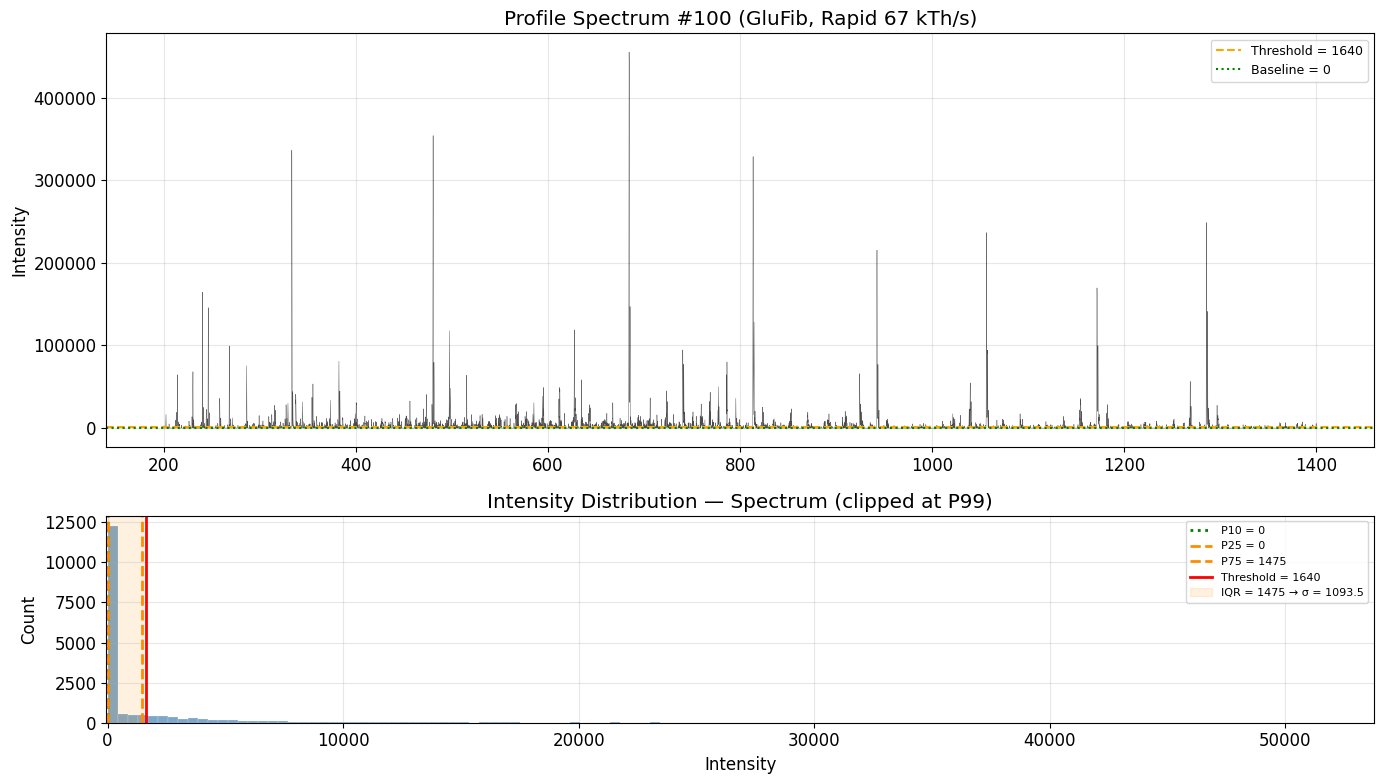


Real spectrum: 18000 total points
  13695 (76.1%) noise/baseline
  4305 (23.9%) signal
  IQR = 1475 − 0 = 1475 → σ = 1093.5


In [61]:
# --- Real spectrum: profile view + noise threshold ---
fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [2, 1]})

# Top: full profile spectrum
ax = axes[0]
ax.plot(real_mz, real_int, 'k-', lw=0.3, alpha=0.7)
ax.axhline(real_threshold, color='orange', ls='--', lw=1.5,
           label=f'Threshold = {real_threshold:.0f}')
ax.axhline(real_baseline, color='green', ls=':', lw=1.5,
           label=f'Baseline = {real_baseline:.0f}')
ax.set_ylabel('Intensity')
ax.set_title(f'Profile Spectrum #{scan_num} (GluFib, Rapid 67 kTh/s)')
ax.legend(fontsize=9)

# Bottom: intensity histogram + percentiles (same as synthetic)
ax2 = axes[1]
# Clip to a reasonable range for histogram visibility
clip_max = np.percentile(real_int, 99)
ax2.hist(real_int[real_int < clip_max], bins=120, color='steelblue',
         alpha=0.7, edgecolor='white', lw=0.2)

real_sorted = np.sort(real_int)
n_real = len(real_sorted)
rp10 = real_sorted[int(0.10 * n_real)]
rp25 = real_sorted[int(0.25 * n_real)]
rp75 = real_sorted[int(0.75 * n_real)]
r_iqr = rp75 - rp25

for pval, label, color, ls in [
    (rp10, f'P10 = {rp10:.0f}', 'green', ':'),
    (rp25, f'P25 = {rp25:.0f}', 'darkorange', '--'),
    (rp75, f'P75 = {rp75:.0f}', 'darkorange', '--'),
    (real_threshold, f'Threshold = {real_threshold:.0f}', 'red', '-'),
]:
    ax2.axvline(pval, color=color, ls=ls, lw=2, label=label)
ax2.axvspan(rp25, rp75, alpha=0.12, color='darkorange',
            label=f'IQR = {r_iqr:.0f} → σ = {r_iqr/1.349:.1f}')
ax2.set_xlabel('Intensity')
ax2.set_ylabel('Count')
ax2.set_title('Intensity Distribution — Spectrum (clipped at P99)')
ax2.legend(fontsize=8, loc='upper right')
ax2.set_xlim(left=-50)

plt.tight_layout()
plt.show()

n_above_real = np.sum(real_int > real_threshold)
print(f"\nReal spectrum: {n_real} total points")
print(f"  {n_real - n_above_real} ({100*(n_real-n_above_real)/n_real:.1f}%) noise/baseline")
print(f"  {n_above_real} ({100*n_above_real/n_real:.1f}%) signal")
print(f"  IQR = {rp75:.0f} − {rp25:.0f} = {r_iqr:.0f} → σ = {r_iqr/1.349:.1f}")

### Noise Refinement: Per-m/z Windows (Pass 1 → 2)

The rough noise estimate above is a **single global value** for the entire spectrum.
But real spectra often have m/z-dependent noise — higher chemical noise in crowded
regions, detector baseline drift, etc. Centrix addresses this with a **windowed
noise refinement** after the first LASSO pass:

1. **Run LASSO** on all signal regions using the rough noise estimate (Pass 1)
2. **Collect residuals** (y − Aβ) from each fitted region — these represent the
   noise that LASSO couldn't explain with Gaussians
3. **Collect gap intensities** — raw intensities between signal regions (below threshold),
   which are pure noise
4. **Slide a 20 Da window** across the spectrum in **5 Da steps**
   (`--noise-window-da` and `--noise-step-da` CLI parameters)
5. In each window, compute the **RMS** of all gap intensities + LASSO residuals
6. Apply **3-point median smoothing** to remove outlier windows
7. The result is a smooth noise curve σ(m/z) used for **per-region λ** in Pass 2

This means each signal region in Pass 2 gets its own regularization strength
λ = `lambda_factor` × σ(m/z_center), adapting to the local noise floor. Regions
where λ changed by more than 20% from the rough estimate are re-fit; the rest
keep their Pass 1 solutions.

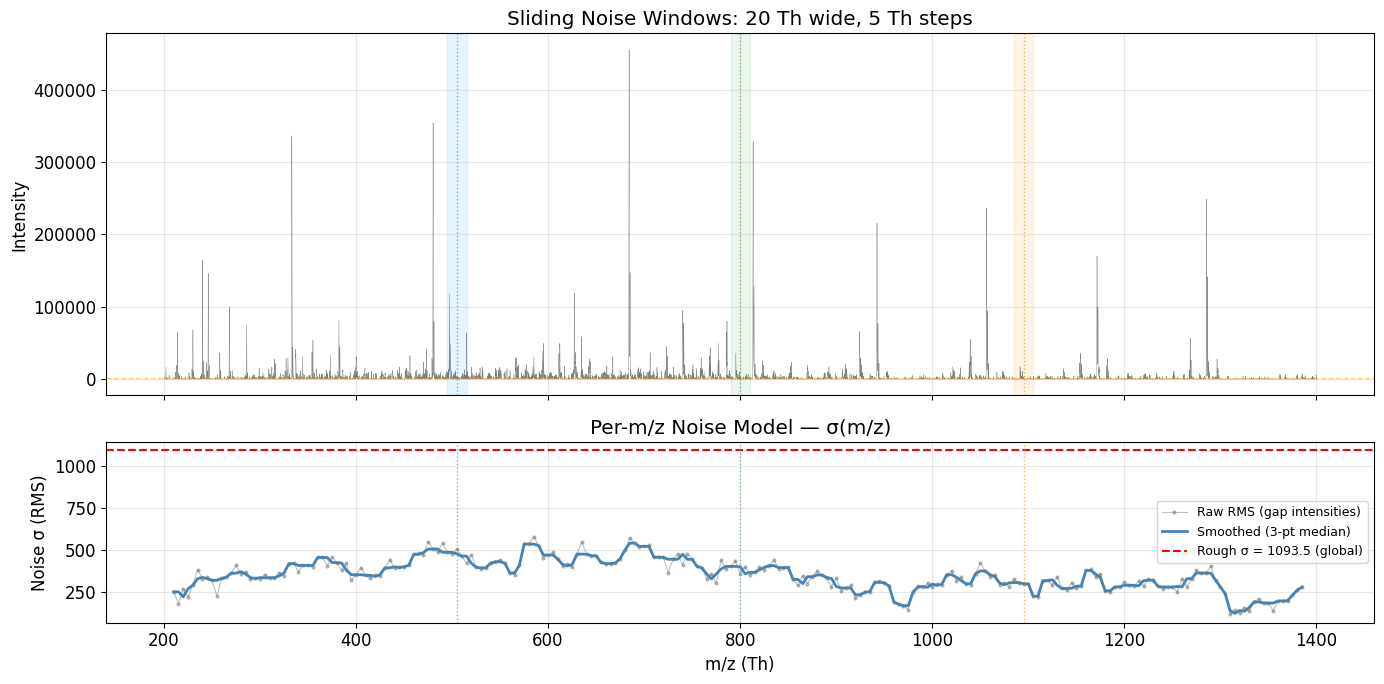

Windows: 236 (20 Da × 5 Da steps)
Noise σ range: 125.2 – 541.3 (global rough = 1093.5)

In Pass 2, LASSO residuals would also be mixed into each window,
giving a more accurate noise estimate than gap intensities alone.


In [62]:
# --- Visualize the sliding-window noise refinement concept ---
# (We don't have LASSO residuals yet — use gap intensities only as a preview)

WINDOW_DA = 20.0  # default --noise-window-da
STEP_DA = 5.0     # default --noise-step-da

# Identify gap points (below threshold = "noise")
gap_mask = real_int <= real_threshold

# Slide windows across the m/z range
mz_min, mz_max = real_mz[0], real_mz[-1]
window_centers = []
window_rms = []

center = mz_min + WINDOW_DA / 2.0
while center <= mz_max - WINDOW_DA / 2.0:
    lo = center - WINDOW_DA / 2.0
    hi = center + WINDOW_DA / 2.0
    # Select gap points in this window
    in_window = (real_mz >= lo) & (real_mz <= hi) & gap_mask
    vals = real_int[in_window]
    if len(vals) >= 5:
        rms = np.sqrt(np.mean(vals ** 2))
        window_centers.append(center)
        window_rms.append(rms)
    center += STEP_DA

window_centers = np.array(window_centers)
window_rms = np.array(window_rms)

# 3-point median smoothing (matches src/noise.rs)
smoothed_rms = np.copy(window_rms)
for i in range(1, len(window_rms) - 1):
    smoothed_rms[i] = np.median(window_rms[i-1:i+2])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7),
                                gridspec_kw={'height_ratios': [2, 1]}, sharex=True)

# Top: spectrum with a few example windows shown
ax1.plot(real_mz, real_int, 'k-', lw=0.3, alpha=0.5)
ax1.axhline(real_threshold, color='orange', ls='--', lw=1, alpha=0.5)
# Highlight a few example windows
example_idxs = [len(window_centers)//4, len(window_centers)//2, 3*len(window_centers)//4]
window_colors = ['#2196F3', '#4CAF50', '#FF9800']
for idx, wc in zip(example_idxs, window_colors):
    c = window_centers[idx]
    ax1.axvspan(c - WINDOW_DA/2, c + WINDOW_DA/2, alpha=0.1, color=wc)
    ax1.axvline(c, color=wc, ls=':', lw=1, alpha=0.7)
ax1.set_ylabel('Intensity')
ax1.set_title(f'Sliding Noise Windows: {WINDOW_DA:.0f} Th wide, {STEP_DA:.0f} Th steps')

# Bottom: noise σ(m/z) curve
ax2.plot(window_centers, window_rms, 'o-', color='gray', ms=2, lw=0.8, alpha=0.5,
         label='Raw RMS (gap intensities)')
ax2.plot(window_centers, smoothed_rms, '-', color='steelblue', lw=2,
         label='Smoothed (3-pt median)')
ax2.axhline(real_noise_sigma, color='red', ls='--', lw=1.5,
            label=f'Rough σ = {real_noise_sigma:.1f} (global)')
for idx, wc in zip(example_idxs, window_colors):
    ax2.axvline(window_centers[idx], color=wc, ls=':', lw=1, alpha=0.7)
ax2.set_xlabel('m/z (Th)')
ax2.set_ylabel('Noise σ (RMS)')
ax2.set_title('Per-m/z Noise Model — σ(m/z)')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"Windows: {len(window_centers)} ({WINDOW_DA:.0f} Da × {STEP_DA:.0f} Da steps)")
print(f"Noise σ range: {smoothed_rms.min():.1f} – {smoothed_rms.max():.1f} "
      f"(global rough = {real_noise_sigma:.1f})")
print(f"\nIn Pass 2, LASSO residuals would also be mixed into each window,")
print(f"giving a more accurate noise estimate than gap intensities alone.")

### Signal Regions on the Real Spectrum

Using the rough noise threshold, Centrix identifies contiguous stretches of
above-threshold data as **signal regions.** These are the only parts of the
spectrum that get LASSO-fitted — everything else is considered noise/baseline.

Found 749 signal regions in spectrum #100
Grid spacing: 0.06667 Th, σ: 0.255 Da


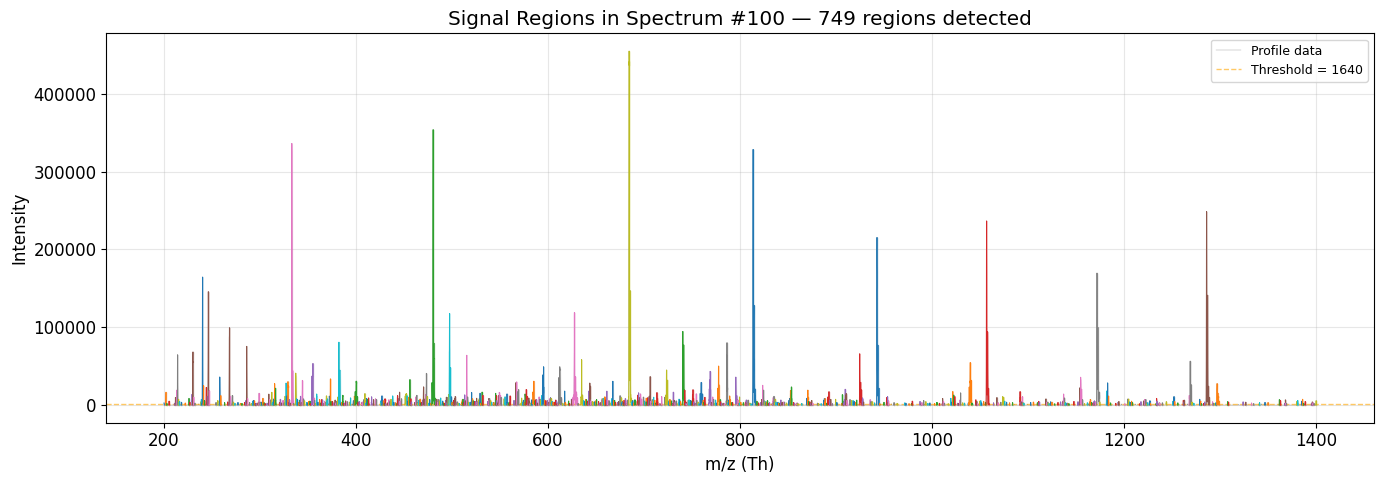


18000 total data points, 9088 in signal regions (50.5%)
8912 gap/noise points (49.5%)


In [63]:
# --- Detect signal regions on the real spectrum ---
# Rapid scan rate: 67 kTh/s → grid spacing 1/15, σ ≈ 0.255 Da
REAL_GRID_SPACING = 1.0 / 15.0  # 0.06667 Th
REAL_SIGMA = 0.255              # σ for 67 kTh/s

real_regions = detect_signal_regions(real_mz, real_int, real_threshold)
print(f"Found {len(real_regions)} signal regions in spectrum #{scan_num}")
print(f"Grid spacing: {REAL_GRID_SPACING:.5f} Th, σ: {REAL_SIGMA} Da")

# Plot the full spectrum with signal regions highlighted
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(real_mz, real_int, 'k-', lw=0.3, alpha=0.4, label='Profile data')
ax.axhline(real_threshold, color='orange', ls='--', lw=1, alpha=0.6,
           label=f'Threshold = {real_threshold:.0f}')

colors = plt.cm.tab10.colors
for i, (s, e) in enumerate(real_regions):
    c = colors[i % len(colors)]
    ax.fill_between(real_mz[s:e+1], 0, real_int[s:e+1], alpha=0.3, color=c)
    ax.plot(real_mz[s:e+1], real_int[s:e+1], '-', color=c, lw=0.6)

ax.set_xlabel('m/z (Th)')
ax.set_ylabel('Intensity')
ax.set_title(f'Signal Regions in Spectrum #{scan_num} — {len(real_regions)} regions detected')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Summary
total_pts = len(real_mz)
region_pts = sum(e - s + 1 for s, e in real_regions)
print(f"\n{total_pts} total data points, {region_pts} in signal regions "
      f"({100*region_pts/total_pts:.1f}%)")
print(f"{total_pts - region_pts} gap/noise points ({100*(total_pts-region_pts)/total_pts:.1f}%)")

### LASSO Fitting on Real Signal Regions

Now let's apply the full LASSO pipeline to the 820–860 Th window.
For each signal region in the window:

1. Build the Gaussian basis grid and design matrix **A**
2. Compute **Aᵀy** (the projection of data onto each basis function)
3. Compute the **Gram row** (Toeplitz inner products between basis columns)
4. Solve the non-negative LASSO: each non-zero β is a detected centroid

Then two post-processing steps (shown in the cell after the fit visualization):

**Step A — Sub-grid refinement + area scaling:**
- Parabolic interpolation on ln(β) for sub-grid m/z positions
- Convert β amplitudes to integrated areas: `intensity = β × σ√(2π) / h`

**Step B — Merge nearby centroids:**
- Centroids closer than σ are merged by intensity-weighted averaging
- Prevents β-splitting artifacts (two adjacent grid coefficients for one real peak)

In [73]:
# --- Non-negative LASSO solver (matches src/lasso.rs) ---

def compute_gram_row(sigma, grid_spacing, n_terms=None):
    """Toeplitz Gram row: G[j,k] = gram_row[|j-k|] for Gaussian basis.
    gram_row[d] = (σ√π / h) · exp(-(d·h)² / (4σ²))
    The σ√π/h normalization is critical — it equals the actual column norm ‖a_j‖²
    for the discrete sum on a uniform grid. Without it, β values are way too large
    and the fit overshoots the data (matches src/basis.rs)."""
    if n_terms is None:
        n_terms = int(6 * sigma / grid_spacing) + 1
    h = grid_spacing
    norm = sigma * np.sqrt(np.pi) / h  # discrete sum approximation of ‖a_j‖²
    row = np.zeros(n_terms)
    for d in range(n_terms):
        row[d] = norm * np.exp(-(d * h) ** 2 / (4 * sigma ** 2))
    return row

def solve_nonneg_lasso(aty, gram_row, lam, warm_start=None, max_iter=2000, tol=1e-6):
    """Non-negative LASSO via coordinate descent (matches src/lasso.rs)."""
    n = len(aty)
    g0 = gram_row[0]
    beta = np.array(warm_start, dtype=float) if warm_start is not None else np.zeros(n)
    max_dist = len(gram_row)

    for iteration in range(max_iter):
        max_delta = 0.0
        for j in range(n):
            # ρ_j = aty[j] - Σ_{k≠j} gram_row[|j-k|] β_k
            lo = max(0, j - max_dist + 1)
            hi = min(n, j + max_dist)
            dot = sum(gram_row[abs(j - k)] * beta[k] for k in range(lo, hi))
            rho = aty[j] - dot + g0 * beta[j]
            beta_new = max(0.0, rho - lam) / g0
            max_delta = max(max_delta, abs(beta_new - beta[j]))
            beta[j] = beta_new
        if max_delta < tol:
            break
    return beta, iteration + 1

# --- Fixed 820–860 Th window (moderate-intensity region) ---
LAMBDA_FACTOR = 3.0  # default
WIN_LO = 820.0
WIN_HI = 860.0

# Mask of data points in this window
win_mask = (real_mz >= WIN_LO) & (real_mz <= WIN_HI)
win_mz = real_mz[win_mask]
win_int = real_int[win_mask]

# Find signal regions that overlap this window
win_regions = []
for i, (s, e) in enumerate(real_regions):
    if real_mz[e] >= WIN_LO and real_mz[s] <= WIN_HI:
        s2 = max(s, np.searchsorted(real_mz, WIN_LO))
        e2 = min(e, np.searchsorted(real_mz, WIN_HI, side='right') - 1)
        if e2 > s2:
            win_regions.append((s2, e2))

gram_row = compute_gram_row(REAL_SIGMA, REAL_GRID_SPACING)
print(f"Window: [{WIN_LO:.1f}, {WIN_HI:.1f}] Th")
print(f"  {len(win_mz)} data points, {len(win_regions)} signal regions")
print(f"  gram_row[0] = {gram_row[0]:.3f} (= σ√π/h = {REAL_SIGMA}×√π/{REAL_GRID_SPACING:.5f})")

# --- LASSO with rough noise estimate ---
rough_lambda = LAMBDA_FACTOR * real_noise_sigma
print(f"\nλ = {LAMBDA_FACTOR} × σ_noise = {LAMBDA_FACTOR} × {real_noise_sigma:.1f} = {rough_lambda:.1f}")

pass1_results = []
for s, e in win_regions:
    rmz = real_mz[s:e+1]
    rint = real_int[s:e+1].astype(float)
    grid = build_grid(rmz[0], rmz[-1], REAL_GRID_SPACING)
    A = build_design_matrix(rmz, grid, REAL_SIGMA)
    aty = A.T @ rint
    beta, n_iter = solve_nonneg_lasso(aty, gram_row, rough_lambda)
    fit = A @ beta
    residuals = rint - fit
    n_peaks = np.sum(beta > 0)
    pass1_results.append({
        'mz': rmz, 'int': rint, 'grid': grid, 'A': A, 'aty': aty,
        'beta': beta, 'fit': fit, 'residuals': residuals,
        'n_peaks': n_peaks, 'n_iter': n_iter
    })

total_peaks_p1 = sum(r['n_peaks'] for r in pass1_results)
print(f"  {len(pass1_results)} regions fitted, {total_peaks_p1} raw centroids detected")

Window: [820.0, 860.0] Th
  600 data points, 35 signal regions
  gram_row[0] = 6.780 (= σ√π/h = 0.255×√π/0.06667)

λ = 3.0 × σ_noise = 3.0 × 1093.5 = 3280.4
  35 regions fitted, 46 raw centroids detected


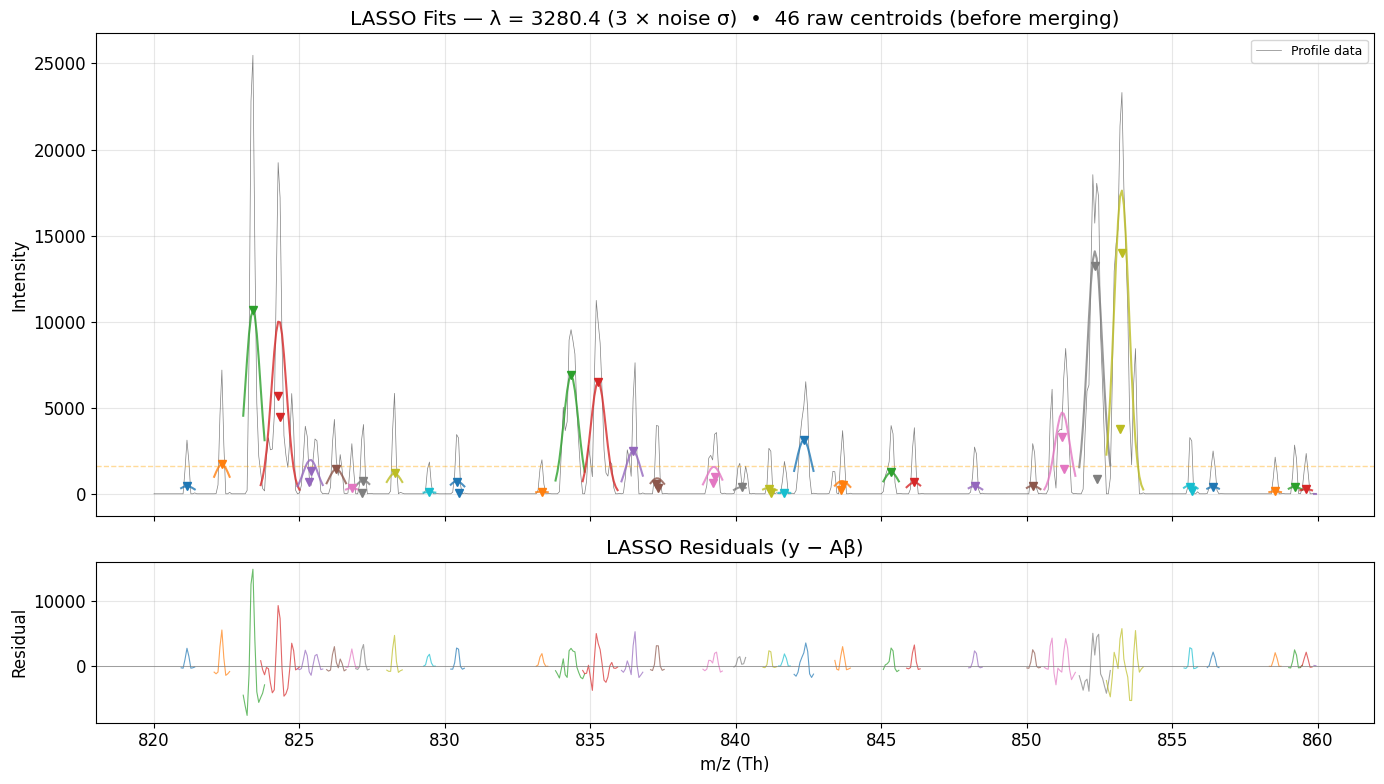

Residuals: 355 points from 35 regions


In [74]:
# --- Visualize LASSO fits in the window ---

fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 1]},
                          sharex=True)

# Panel 1: Data + LASSO fits + detected raw centroids (β > 0)
ax = axes[0]
ax.plot(win_mz, win_int, 'k-', lw=0.5, alpha=0.5, label='Profile data')
ax.axhline(real_threshold, color='orange', ls='--', lw=1, alpha=0.4)

for i, r in enumerate(pass1_results):
    c = colors[i % len(colors)]
    ax.plot(r['mz'], r['fit'], '-', color=c, lw=1.5, alpha=0.8)
    for j, b in enumerate(r['beta']):
        if b > 0:
            ax.plot(r['grid'][j], b, 'v', color=c, ms=6, zorder=5)

ax.set_ylabel('Intensity')
ax.set_title(f'LASSO Fits — λ = {rough_lambda:.1f} (3 × noise σ)  •  '
             f'{total_peaks_p1} raw centroids (before merging)')
ax.legend(fontsize=9, loc='upper right')

# Panel 2: Residuals
ax = axes[1]
for i, r in enumerate(pass1_results):
    c = colors[i % len(colors)]
    ax.plot(r['mz'], r['residuals'], '-', color=c, lw=0.8, alpha=0.7)
ax.axhline(0, color='gray', ls='-', lw=0.5)
ax.set_ylabel('Residual')
ax.set_xlabel('m/z (Th)')
ax.set_title('LASSO Residuals (y − Aβ)')

plt.tight_layout()
plt.show()

print(f"Residuals: {sum(len(r['residuals']) for r in pass1_results)} points from {len(pass1_results)} regions")

Step A — Sub-grid refinement + area scaling:
  46 centroids (all β > 0, area-scaled by σ√(2π)/h = 9.59)
  area_scale = σ√(2π)/h = 0.255×√(2π)/0.06667 = 9.59

Step B — Merge centroids closer than σ = 0.255 Da:
  46 → 34 centroids (12 removed by merging)

  12 merge events:
    [824.2667, 824.3333] (Δ=0.0667) → 824.2961 Da
    [825.3333, 825.4000] (Δ=0.0667) → 825.3779 Da
    [827.1333, 827.2000] (Δ=0.0667) → 827.1976 Da
    [830.4000, 830.4667] (Δ=0.0667) → 830.4050 Da
    [837.2667, 837.3333] (Δ=0.0667) → 837.2914 Da
    [839.2000, 839.2667] (Δ=0.0667) → 839.2404 Da
    [841.1333, 841.2000] (Δ=0.0667) → 841.1432 Da
    [843.6000, 843.6667] (Δ=0.0667) → 843.6457 Da


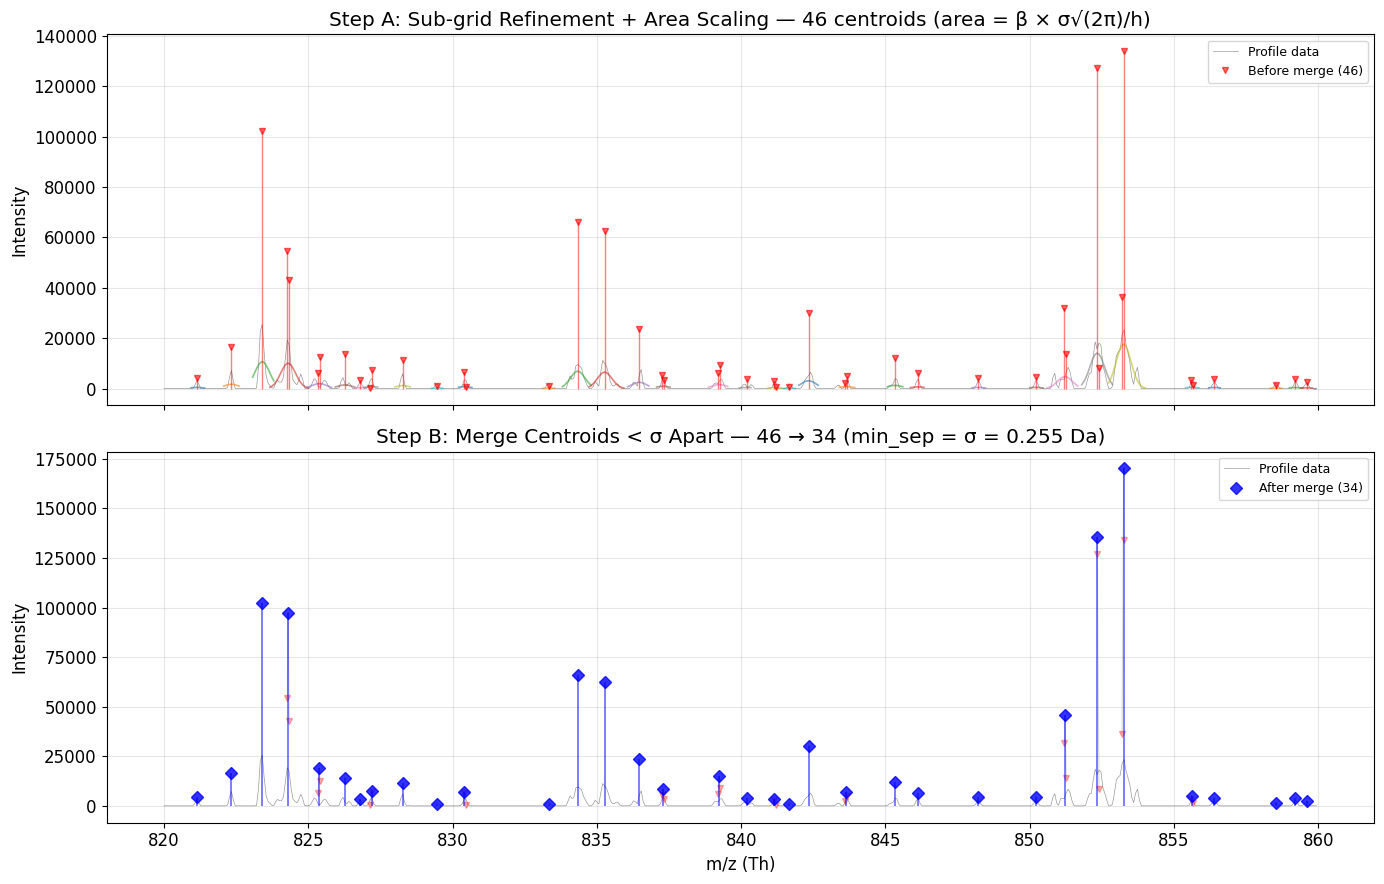


Final centroid list (34 centroids):
         m/z  Area (intensity)
    821.1333            4265.8
    822.3333           16357.8
    823.4000          102168.4
    824.2961           97306.2
    825.3779           19051.0
    826.2667           13828.6
    826.8000            3252.8
    827.1976            7471.4
    828.2667           11361.4
    829.4667             913.8
    830.4050            7009.6
    833.3333            1182.3
    834.3333           65911.0
    835.2667           62469.8
    836.4667           23736.1
    837.2914            8736.5
    839.2404           15211.6
    840.2000            3764.9
    841.1432            3402.1
    841.6667             687.6
    842.3333           29964.9
    843.6457            7218.2
    845.3333           11992.1
    846.1333            6329.5
    848.2000            4243.4
    850.2000            4473.6
    851.2202           45656.6
    852.3374          135362.0
    853.2525          170092.4
    855.6180            4853.3
  

In [75]:
# --- Sub-grid refinement + area scaling + centroid merging ---
# Matches src/lasso.rs::refine_subgrid then src/centroid.rs lines 288-326

def refine_subgrid(beta, grid):
    """Parabolic interpolation of ln(β) for sub-grid m/z refinement.
    If β[j-1], β[j], β[j+1] are all > 0, fit a parabola to ln(β) and shift
    the centroid to the vertex. Offset clamped to ±0.5×h (half grid spacing).
    (matches src/lasso.rs::refine_subgrid)."""
    centroids = []
    n = len(beta)
    j = 0
    while j < n:
        if beta[j] <= 0:
            j += 1
            continue
        # Try parabola refinement using neighbors
        if j > 0 and j + 1 < n and beta[j-1] > 0 and beta[j+1] > 0:
            ly0, ly1, ly2 = np.log(beta[j-1]), np.log(beta[j]), np.log(beta[j+1])
            h = grid[j] - grid[j-1]
            if h > 1e-9:
                a = (ly0 - 2*ly1 + ly2) / (2 * h * h)
                if a < 0:  # parabola opens downward (valid peak)
                    b = (ly2 - ly0) / (2 * h)
                    offset = -b / (2 * a)
                    if abs(offset) <= 0.5 * h:
                        centroids.append((grid[j] + offset, beta[j]))
                        j += 1
                        continue
        centroids.append((grid[j], beta[j]))
        j += 1
    return centroids

def merge_nearby_centroids(sorted_centroids, min_sep):
    """Merge centroids within min_sep of each other by intensity-weighted average.
    Operates on area-scaled centroids (matching Rust order: scale then merge).
    (matches src/centroid.rs::merge_nearby_centroids)."""
    if not sorted_centroids:
        return []
    result = []
    cur_mz, cur_int = sorted_centroids[0]
    for mz_next, int_next in sorted_centroids[1:]:
        if mz_next - cur_mz < min_sep:
            total = cur_int + int_next
            if total > 0:
                cur_mz = (cur_mz * cur_int + mz_next * int_next) / total
                cur_int = total
        else:
            result.append((cur_mz, cur_int))
            cur_mz, cur_int = mz_next, int_next
    result.append((cur_mz, cur_int))
    return result

# ── Step A: Sub-grid refinement + area scaling ────────────────────────────────
# Rust order (src/centroid.rs lines 288-293):
#   1. refine_subgrid(&output.beta, &grid) → (mz, β_amplitude) pairs
#   2. intensity = amplitude × area_scale    (β → integrated Gaussian area)
#   3. merge_nearby_centroids(sorted, min_sep)
#
# area_scale = σ√(2π) / h  — the discrete sum of exp(-(kh)²/(2σ²)) over all grid
# points, so β × area_scale ≈ the integrated area under the Gaussian.

MIN_SEP = REAL_SIGMA  # merge threshold = σ (matches Centrix default)
AREA_SCALE = REAL_SIGMA * np.sqrt(2 * np.pi) / REAL_GRID_SPACING  # β → integrated area

all_refined_centroids = []  # (mz, area_scaled_intensity) — before merging

for r in pass1_results:
    refined = refine_subgrid(r['beta'], r['grid'])
    # Area-scale immediately (matches Rust: scale before merge)
    scaled = [(mz, amp * AREA_SCALE) for mz, amp in refined]
    all_refined_centroids.extend(scaled)

# Sort by m/z (matches Rust: sort globally across all regions before merge)
all_refined_centroids.sort(key=lambda x: x[0])

print(f"Step A — Sub-grid refinement + area scaling:")
print(f"  {len(all_refined_centroids)} centroids (all β > 0, area-scaled by σ√(2π)/h = {AREA_SCALE:.2f})")
print(f"  area_scale = σ√(2π)/h = {REAL_SIGMA}×√(2π)/{REAL_GRID_SPACING:.5f} = {AREA_SCALE:.2f}")

# ── Step B: Merge nearby centroids (<σ apart) ────────────────────────────────
merged_centroids = merge_nearby_centroids(all_refined_centroids, MIN_SEP)

print(f"\nStep B — Merge centroids closer than σ = {MIN_SEP} Da:")
print(f"  {len(all_refined_centroids)} → {len(merged_centroids)} centroids "
      f"({len(all_refined_centroids) - len(merged_centroids)} removed by merging)")

# Identify merge events for annotation
merge_examples = []
i = 0
while i < len(all_refined_centroids):
    group = [all_refined_centroids[i]]
    j = i + 1
    while j < len(all_refined_centroids) and all_refined_centroids[j][0] - group[-1][0] < MIN_SEP:
        group.append(all_refined_centroids[j])
        j += 1
    if len(group) > 1:
        total_int = sum(a for _, a in group)
        merged_mz = sum(m * a for m, a in group) / total_int if total_int > 0 else group[0][0]
        merge_examples.append((group, (merged_mz, total_int)))
    i = j

if merge_examples:
    print(f"\n  {len(merge_examples)} merge events:")
    for group, (merged_mz, merged_int) in merge_examples[:8]:
        positions = ", ".join(f"{m:.4f}" for m, _ in group)
        seps = ", ".join(f"{group[k+1][0]-group[k][0]:.4f}" for k in range(len(group)-1))
        print(f"    [{positions}] (Δ={seps}) → {merged_mz:.4f} Da")

# ── Visualization: two panels showing before/after merge ──────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# Panel 1: Profile data + LASSO fits + area-scaled centroids BEFORE merging
ax = axes[0]
ax.plot(win_mz, win_int, 'k-', lw=0.5, alpha=0.4, label='Profile data')
for i, r in enumerate(pass1_results):
    c = colors[i % len(colors)]
    ax.plot(r['mz'], r['fit'], '-', color=c, lw=1.2, alpha=0.6)

# Plot area-scaled centroids as stems (stick spectrum)
pre_mzs = [m for m, _ in all_refined_centroids]
pre_ints = [a for _, a in all_refined_centroids]
ax.vlines(pre_mzs, 0, pre_ints, colors='red', lw=1, alpha=0.5, zorder=4)
ax.plot(pre_mzs, pre_ints, 'v', color='red', ms=5, alpha=0.6,
        label=f'Before merge ({len(all_refined_centroids)})', zorder=5)
ax.set_ylabel('Intensity')
ax.set_title(f'Step A: Sub-grid Refinement + Area Scaling — '
             f'{len(all_refined_centroids)} centroids (area = β × σ√(2π)/h)')
ax.legend(fontsize=9, loc='upper right')

# Panel 2: Profile data + merged centroids
ax = axes[1]
ax.plot(win_mz, win_int, 'k-', lw=0.5, alpha=0.4, label='Profile data')

# Plot merged centroids as stems
merged_mzs = [m for m, _ in merged_centroids]
merged_ints = [a for _, a in merged_centroids]
ax.vlines(merged_mzs, 0, merged_ints, colors='blue', lw=1.2, alpha=0.6, zorder=4)
ax.plot(merged_mzs, merged_ints, 'D', color='blue', ms=6, alpha=0.8,
        label=f'After merge ({len(merged_centroids)})', zorder=5)

# Highlight merge events: show pre-merge positions in red
if merge_examples:
    for group, (merged_mz, merged_int) in merge_examples:
        for m, a in group:
            ax.plot(m, a, 'v', color='red', ms=5, alpha=0.3, zorder=3)
            ax.plot([m, merged_mz], [a, merged_int], '-', color='gray',
                    lw=0.8, alpha=0.3)

ax.set_ylabel('Intensity')
ax.set_xlabel('m/z (Th)')
ax.set_title(f'Step B: Merge Centroids < σ Apart — '
             f'{len(all_refined_centroids)} → {len(merged_centroids)} '
             f'(min_sep = σ = {MIN_SEP} Da)')
ax.legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.show()

# Summary table
print(f"\nFinal centroid list ({len(merged_centroids)} centroids):")
print(f"  {'m/z':>10}  {'Area (intensity)':>16}")
for mz_m, int_m in merged_centroids:
    print(f"  {mz_m:>10.4f}  {int_m:>16.1f}")

## Step 2: Signal Region Detection

Find contiguous stretches of above-threshold data, then:
1. **Merge** segments separated by ≤ 2 points (bridge small valleys)
2. **Extend** each region by 3 points on each side (capture tails)
3. **Filter** regions narrower than 3 points

Every detected region goes through LASSO — no fast-path shortcuts.

In [67]:
def detect_signal_regions(mz, intensity, threshold,
                          merge_gap=2, extension=3, min_width=3):
    """Detect signal regions (matches src/signal.rs)."""
    above = intensity > threshold
    n = len(mz)

    # Find contiguous above-threshold segments
    segments = []
    in_seg = False
    for i in range(n):
        if above[i] and not in_seg:
            seg_start = i
            in_seg = True
        elif not above[i] and in_seg:
            segments.append((seg_start, i - 1))
            in_seg = False
    if in_seg:
        segments.append((seg_start, n - 1))

    if not segments:
        return []

    # Merge segments separated by ≤ merge_gap points
    merged = [segments[0]]
    for s, e in segments[1:]:
        if s <= merged[-1][1] + merge_gap + 1:
            merged[-1] = (merged[-1][0], e)
        else:
            merged.append((s, e))

    # Extend, clamp, filter
    regions = []
    for s, e in merged:
        s2 = max(0, s - extension)
        e2 = min(n - 1, e + extension)
        if e2 - s2 + 1 >= min_width:
            regions.append((s2, e2))
    return regions

regions = detect_signal_regions(mz, intensity, threshold)
print(f"Found {len(regions)} signal regions:")
for i, (s, e) in enumerate(regions):
    print(f"  Region {i}: indices [{s}..{e}], "
          f"m/z [{mz[s]:.3f}..{mz[e]:.3f}], "
          f"width {mz[e]-mz[s]:.3f} Da, "
          f"{e-s+1} points")

Found 2 signal regions:
  Region 0: indices [11..24], m/z [499.375..501.000], width 1.625 Da, 14 points
  Region 1: indices [36..48], m/z [502.500..504.000], width 1.500 Da, 13 points


### Visualize Detected Regions

Each colored region will be independently processed by the LASSO solver.

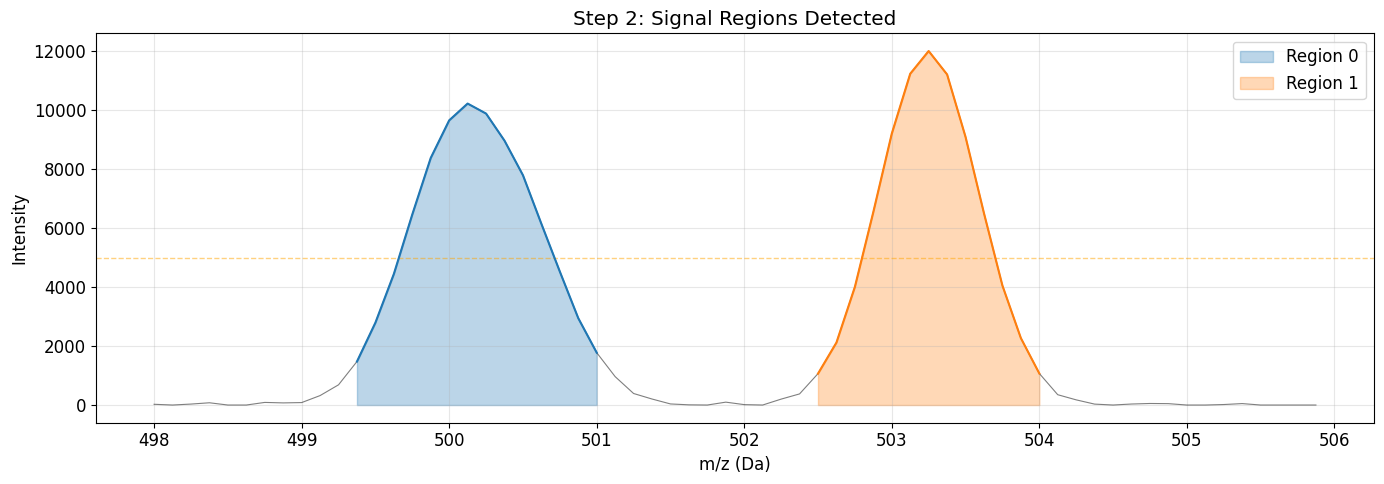

In [68]:
colors = plt.cm.tab10.colors

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(mz, intensity, 'k-', lw=0.8, alpha=0.5)
ax.axhline(threshold, color='orange', ls='--', lw=1, alpha=0.5)

for i, (s, e) in enumerate(regions):
    color = colors[i % len(colors)]
    ax.fill_between(mz[s:e+1], 0, intensity[s:e+1],
                    alpha=0.3, color=color, label=f'Region {i}')
    ax.plot(mz[s:e+1], intensity[s:e+1], '-', color=color, lw=1.5)

ax.set_xlabel('m/z (Da)')
ax.set_ylabel('Intensity')
ax.set_title('Step 2: Signal Regions Detected')
ax.legend()
plt.tight_layout()
plt.show()

## Step 3: Build the Gaussian Basis Matrix

For each region, Centrix builds a design matrix **A** where each column is a
Gaussian basis function centered at a grid position:

$$A_{i,j} = \exp\!\left(-\frac{(m/z_i - g_j)^2}{2\sigma^2}\right)$$

The grid uses the same spacing as the profile data (0.125 Da for MS2), so the
system is square or near-square. Let's examine the overlapping region (peaks A & B).

Region 0: 14 data points, 16 basis functions
Design matrix A: shape (14, 16)


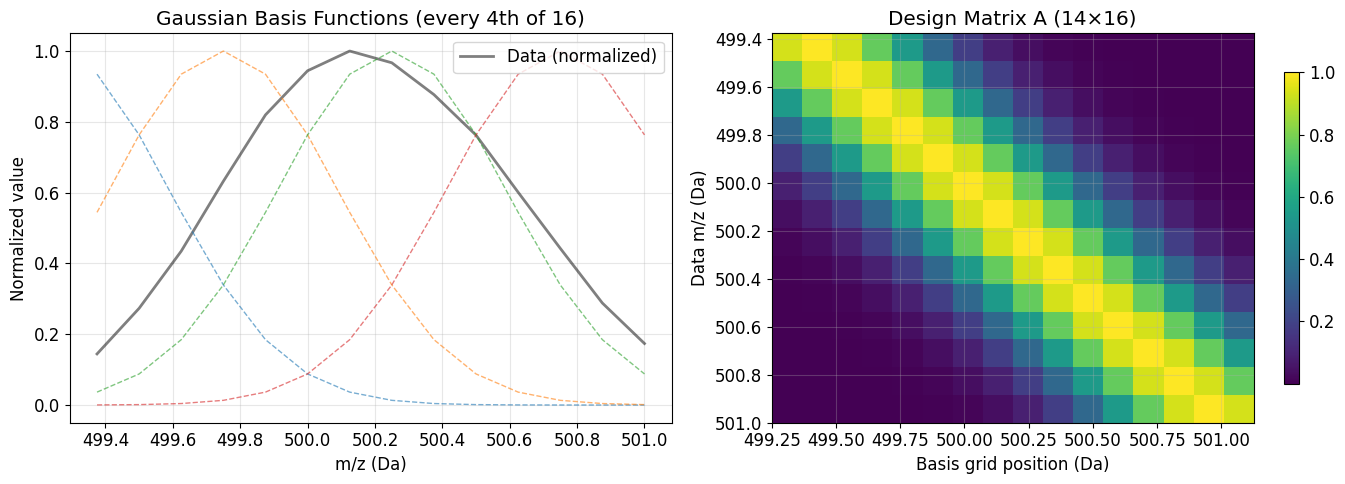

In [69]:
def build_grid(mz_start, mz_end, spacing):
    """Build grid positions covering [mz_start, mz_end] (matches src/basis.rs)."""
    k_start = int(np.floor(mz_start / spacing)) - 1
    positions = []
    k = k_start
    while True:
        pos = k * spacing
        if pos > mz_end + spacing:
            break
        if pos >= mz_start - spacing:
            positions.append(pos)
        k += 1
    return np.array(positions)

def build_design_matrix(mz_data, grid, sigma):
    """Build A[i,j] = exp(-(mz[i] - grid[j])² / (2σ²)) (matches src/basis.rs)."""
    inv_2sig2 = -1.0 / (2.0 * sigma * sigma)
    n_data = len(mz_data)
    n_basis = len(grid)
    A = np.zeros((n_data, n_basis))
    for j in range(n_basis):
        d = mz_data - grid[j]
        A[:, j] = np.exp(d * d * inv_2sig2)
    return A

# Focus on the overlapping region (region 0: peaks A & B)
r0_s, r0_e = regions[0]
mz_region = mz[r0_s:r0_e+1]
int_region = intensity[r0_s:r0_e+1]

grid = build_grid(mz_region[0], mz_region[-1], GRID_SPACING)
A = build_design_matrix(mz_region, grid, SIGMA)

print(f"Region 0: {len(mz_region)} data points, {len(grid)} basis functions")
print(f"Design matrix A: shape {A.shape}")

# Visualize the basis matrix columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: a few example basis functions
ax1.plot(mz_region, int_region / int_region.max(), 'k-', lw=2, alpha=0.5, label='Data (normalized)')
for j in range(0, len(grid), 4):  # show every 4th basis column
    ax1.plot(mz_region, A[:, j], '--', alpha=0.6, lw=1)
ax1.set_xlabel('m/z (Da)')
ax1.set_ylabel('Normalized value')
ax1.set_title(f'Gaussian Basis Functions (every 4th of {len(grid)})')
ax1.legend()

# Right: design matrix heatmap
im = ax2.imshow(A, aspect='auto', cmap='viridis',
                extent=[grid[0], grid[-1], mz_region[-1], mz_region[0]])
ax2.set_xlabel('Basis grid position (Da)')
ax2.set_ylabel('Data m/z (Da)')
ax2.set_title(f'Design Matrix A ({A.shape[0]}×{A.shape[1]})')
plt.colorbar(im, ax=ax2, shrink=0.8)

plt.tight_layout()
plt.show()